In [2]:
# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid", context="talk")

# ============================================================
# 1. LOAD DATA
# ============================================================

# Load the preprocessed dataset
df = pd.read_csv("data/processed/operations_cleaned.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Preview dataset
df.head()


,date,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,capacity_violation,opening_overflow_tonnes,closing_overflow_tonnes
0,2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,False,0.0,0.0
1,2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,False,0.0,0.0
2,2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,False,0.0,0.0
3,2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,False,0.0,0.0
4,2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,False,0.0,0.0


In [3]:
# ============================================================
# 2. BASIC DATA OVERVIEW
# ============================================================

# Shape of dataset
print("Dataset shape:", df.shape)

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

# Unique sites and cement types
print("Number of sites:", df['site_id'].nunique())
print("Cement types:", df['cement_type'].unique())


Dataset shape: (32880, 16)
Number of sites: 30
Cement types: <StringArray>
['CEM_II', 'CEM_I', 'CEM_III']
Length: 3, dtype: str


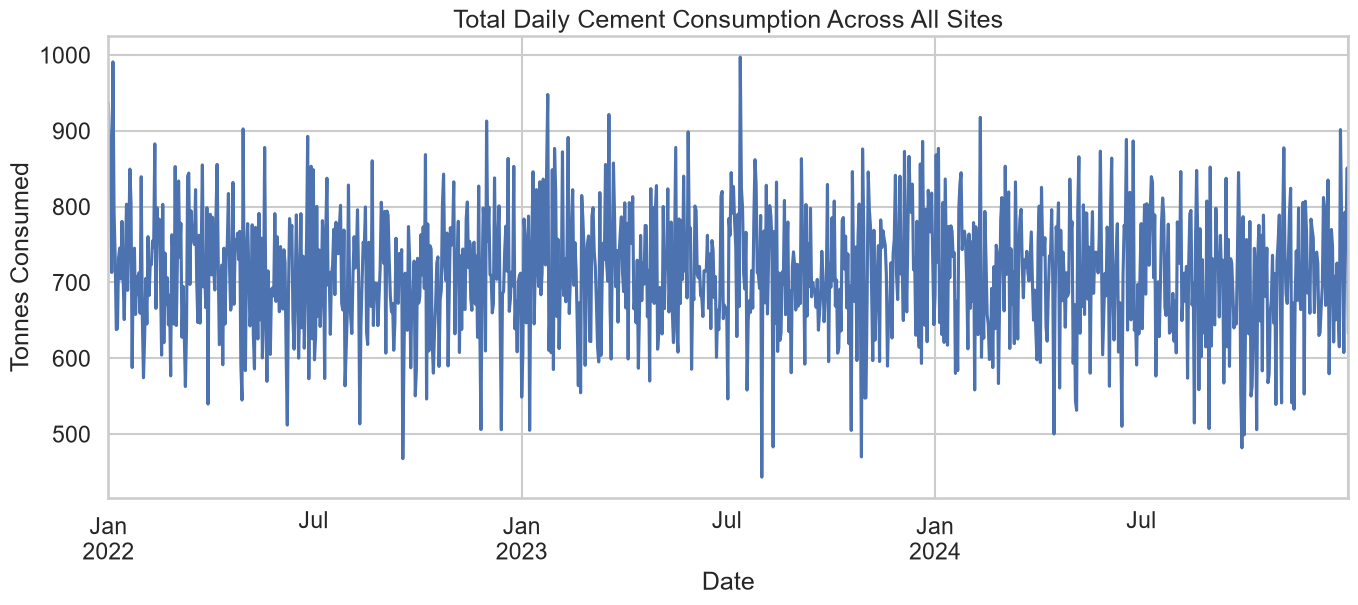

In [4]:
# ============================================================
# 3. DAILY CONSUMPTION TRENDS
# Demand Patterns Over Time
# ============================================================

plt.figure(figsize=(16,6))
df.groupby('date')['consumed_tonnes'].sum().plot()
plt.title("Total Daily Cement Consumption Across All Sites")
plt.xlabel("Date")
plt.ylabel("Tonnes Consumed")
plt.show()


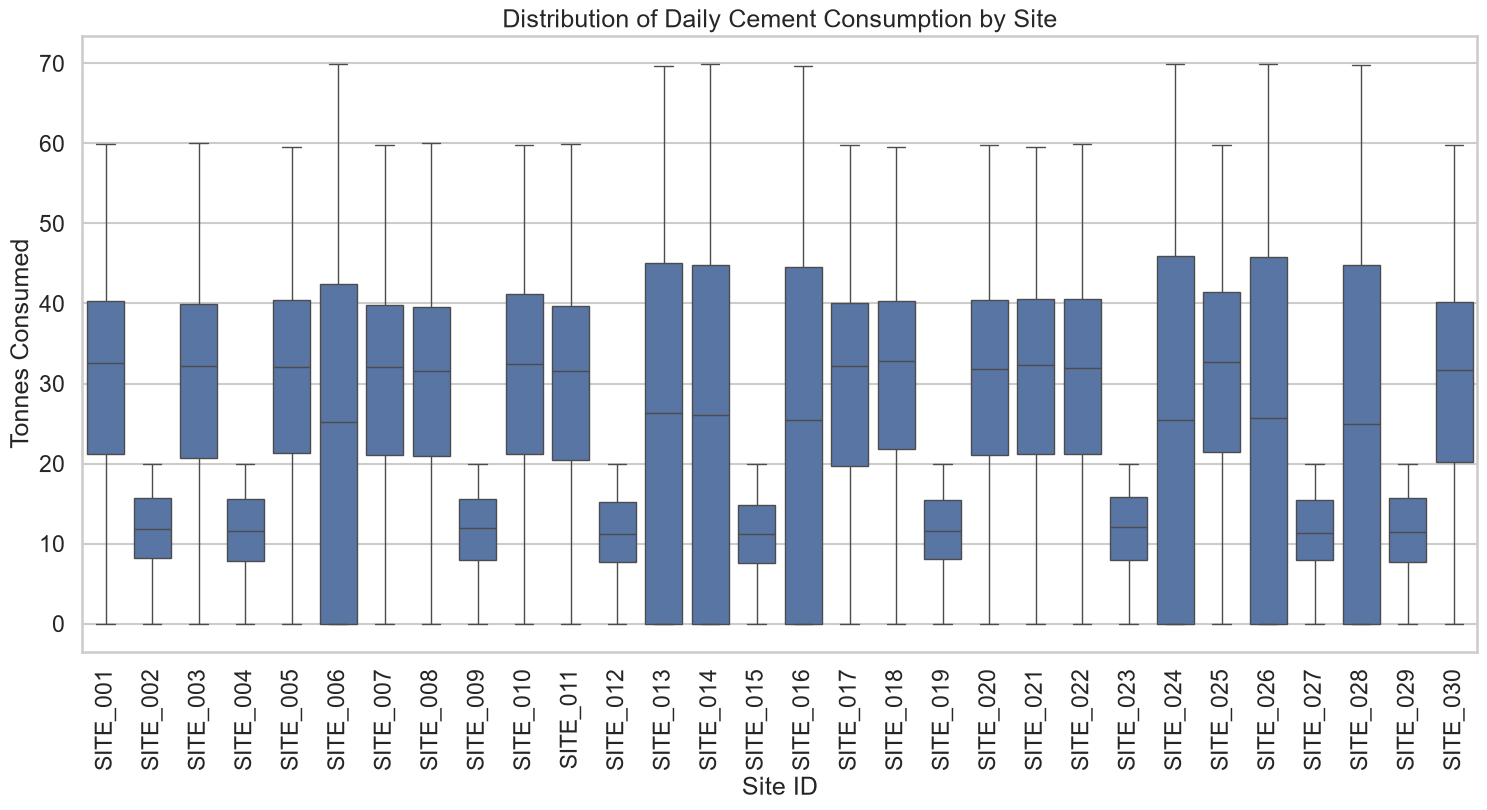

In [5]:
# ============================================================
# 4. SITE-LEVEL CONSUMPTION PATTERNS
# Site-Level Demand Patterns
# ============================================================

plt.figure(figsize=(18,8))
sns.boxplot(data=df, x='site_id', y='consumed_tonnes')
plt.xticks(rotation=90)
plt.title("Distribution of Daily Cement Consumption by Site")
plt.xlabel("Site ID")
plt.ylabel("Tonnes Consumed")
plt.show()


C:\Users\gideo\AppData\Local\Temp\ipykernel_41216\2105119561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cement_type', y='consumed_tonnes', palette="viridis")


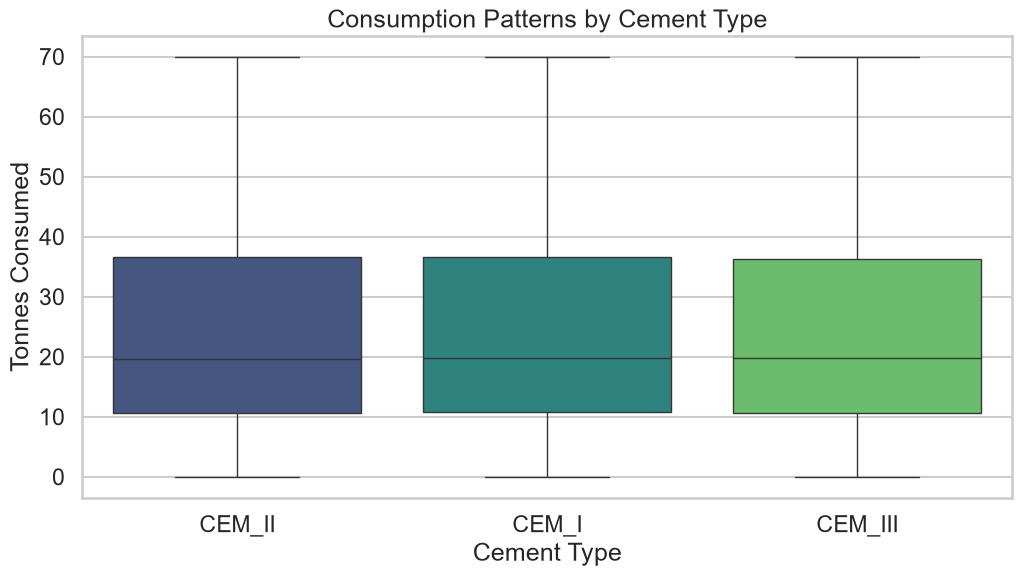

In [6]:
# ============================================================
# 5. CEMENT TYPE CONSUMPTION PATTERNS
# Cement Type Behaviour
# ============================================================

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='cement_type', y='consumed_tonnes', palette="viridis")
plt.title("Consumption Patterns by Cement Type")
plt.xlabel("Cement Type")
plt.ylabel("Tonnes Consumed")
plt.show()


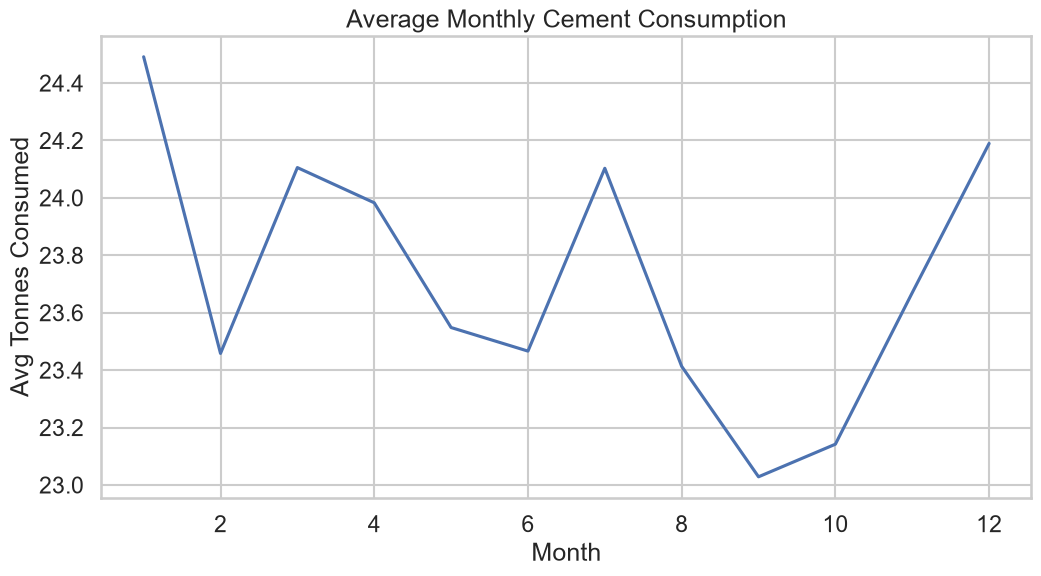

In [7]:
# ============================================================
# 6. SEASONALITY ANALYSIS
# Seasonality & Monthly Trends
# ============================================================

df['month'] = df['date'].dt.month

plt.figure(figsize=(12,6))
sns.lineplot(data=df.groupby('month')['consumed_tonnes'].mean())
plt.title("Average Monthly Cement Consumption")
plt.xlabel("Month")
plt.ylabel("Avg Tonnes Consumed")
plt.show()


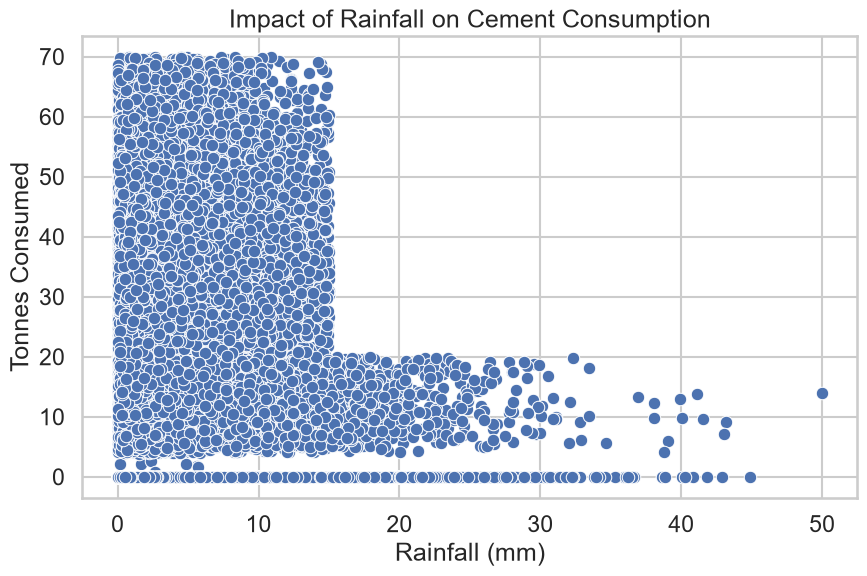

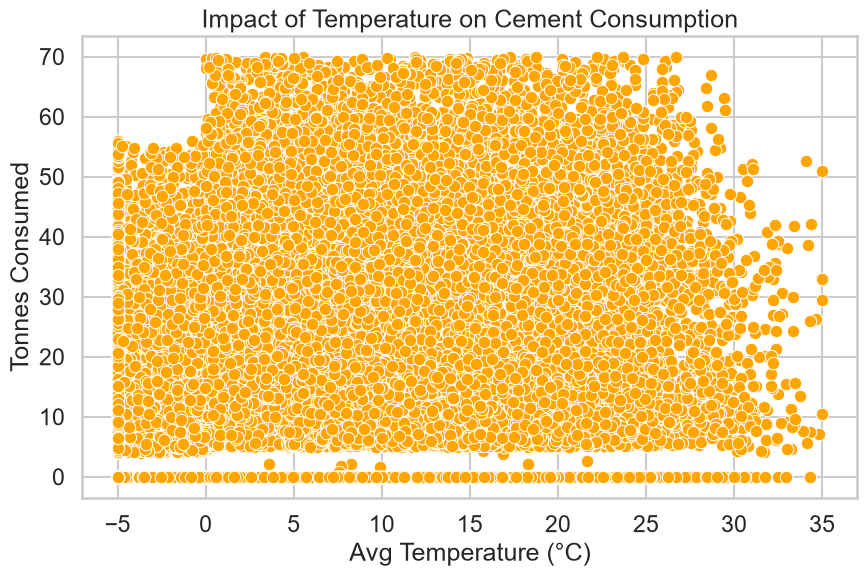

In [8]:
# ============================================================
# 7. WEATHER CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rain_mm', y='consumed_tonnes')
plt.title("Impact of Rainfall on Cement Consumption")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Tonnes Consumed")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='avg_temp_c', y='consumed_tonnes', color='orange')
plt.title("Impact of Temperature on Cement Consumption")
plt.xlabel("Avg Temperature (°C)")
plt.ylabel("Tonnes Consumed")
plt.show()


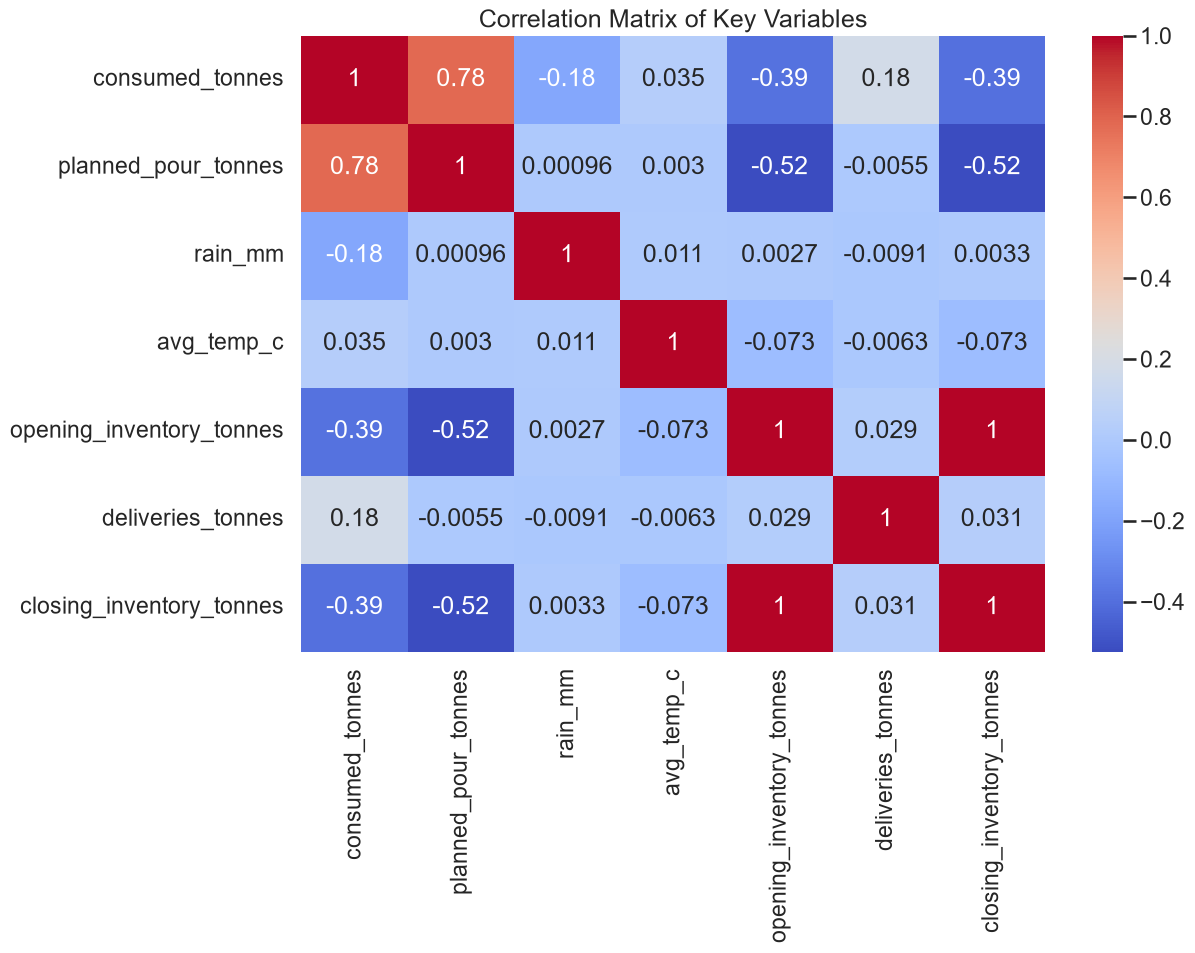

In [9]:
# ============================================================
# 8. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12,8))
sns.heatmap(df[['consumed_tonnes','planned_pour_tonnes','rain_mm','avg_temp_c',
                'opening_inventory_tonnes','deliveries_tonnes','closing_inventory_tonnes']]
            .corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Key Variables")
plt.show()


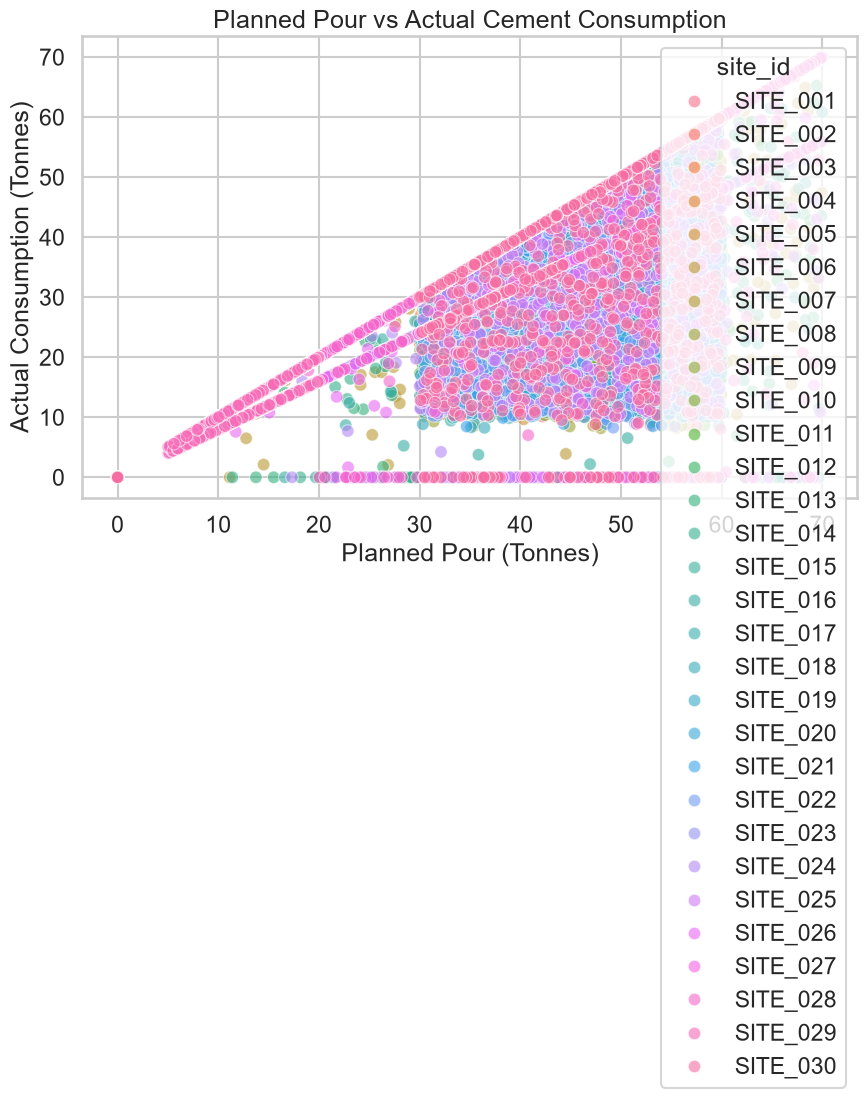

In [10]:
# ============================================================
# 9. PLANNED POUR VS ACTUAL CONSUMPTION
# ============================================================

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='planned_pour_tonnes', y='consumed_tonnes', hue='site_id', alpha=0.6)
plt.title("Planned Pour vs Actual Cement Consumption")
plt.xlabel("Planned Pour (Tonnes)")
plt.ylabel("Actual Consumption (Tonnes)")
plt.show()


In [11]:
# ============================================================
# 10. OUTLIER DETECTION USING IQR
# ============================================================

Q1 = df['consumed_tonnes'].quantile(0.25)
Q3 = df['consumed_tonnes'].quantile(0.75)
IQR = Q3 - Q1

# Define outliers
outliers = df[(df['consumed_tonnes'] < (Q1 - 1.5 * IQR)) |
              (df['consumed_tonnes'] > (Q3 + 1.5 * IQR))]

print("Number of outliers:", outliers.shape[0])
outliers.head()


Number of outliers: 0


,date,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,capacity_violation,opening_overflow_tonnes,closing_overflow_tonnes,month


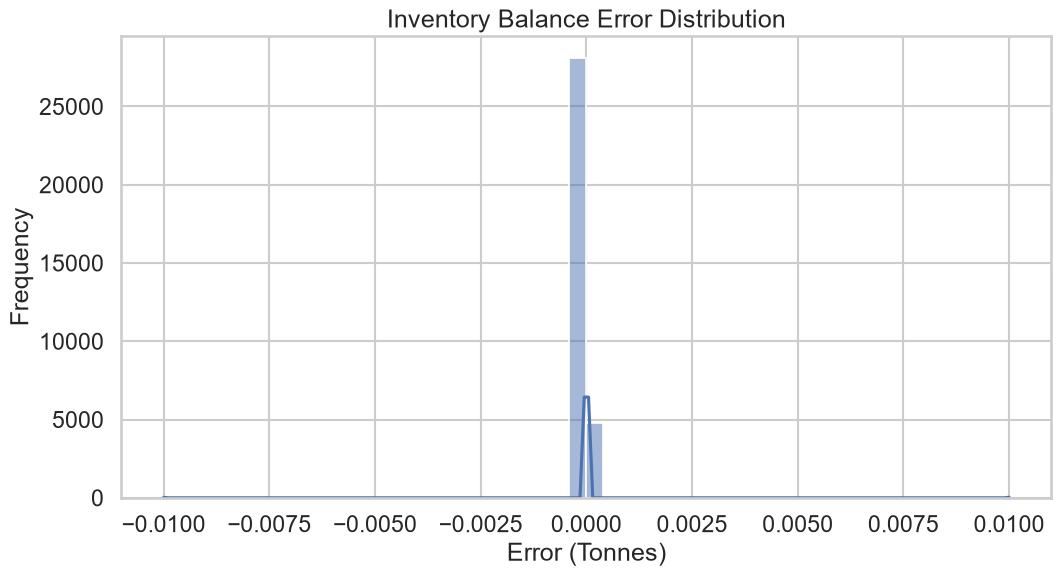

In [12]:
# ============================================================
# 11. INVENTORY BALANCE CHECK
# ============================================================

df['calc_closing'] = df['opening_inventory_tonnes'] + df['deliveries_tonnes'] - df['consumed_tonnes']

# Compare calculated vs actual closing inventory
df['inventory_error'] = df['closing_inventory_tonnes'] - df['calc_closing']

plt.figure(figsize=(12,6))
sns.histplot(df['inventory_error'], bins=50, kde=True)
plt.title("Inventory Balance Error Distribution")
plt.xlabel("Error (Tonnes)")
plt.ylabel("Frequency")
plt.show()
